# Tensorflow构建模型

## 【章节目标】
- 了解tensorflow构建模型的方式
- 掌握tensorflow常用层的使用
- 掌握顺序模型、函数模型和子类化模型等建模方式
- 掌握自定义层的方法
- 熟练使用tensorflow搭建复杂网络模型

## 【章节内容】

###  神经网络实现方式
如图所示，通过堆叠 4 个全连接层，可以获得层数为 4 的神经网络，由于每层均为全连接层，称为全连接网络。其中第 1~3 个全连接层在网络中间，称之为隐藏层 1,2,3，最后一个全连接层的输出作为网络的输出，称为输出层。隐藏层 1,2,3 的输出节点数分别为[256,128,64]，输出层的输出节点数为 10。

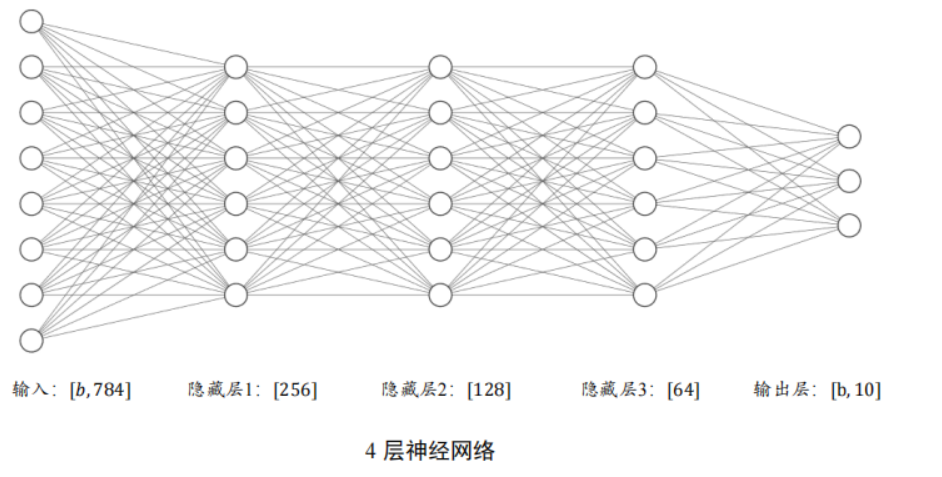

#### 1）张量方式实现(1.x)
- 在 TensorFlow 中，要实现全连接层，只需要定义好权值张量 W 和偏置张量 b，并利用TensorFlow 提供的批量矩阵相乘函数 tf.matmul()即可完成网络层的计算。这也是tensorflow 1.x中的建模方式。

- 对于多层神经网络，以图中网络结构为例，分别定义各层的权值矩阵 W 和偏置向量 b 如下：

In [1]:
import tensorflow as tf
# 隐藏层 1 张量
w1 = tf.Variable(tf.random.truncated_normal([784, 256], stddev = 0.1))
b1 = tf.Variable(tf.zeros([256]))
# 隐藏层 2 张量
w2 = tf.Variable(tf.random.truncated_normal([256, 128], stddev=0.1))
b2 = tf.Variable(tf.zeros([128]))
# 隐藏层 3 张量
w3 = tf.Variable(tf.random.truncated_normal([128, 64], stddev=0.1))
b3 = tf.Variable(tf.zeros([64]))
# 输出层张量
w4 = tf.Variable(tf.random.truncated_normal([64, 10], stddev=0.1))
b4 = tf.Variable(tf.zeros([10]))

2026-04-05 12:50:43.213963: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-05 12:50:43.214136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-05 12:50:43.284961: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-05 12:50:46.995951: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


在计算时，只需要按照网络层的顺序，将上一层的输出送入当前层的输入即可，重复直至最后一层，将输出层的输出作为网络的输出：

In [2]:
x = tf.random.normal([8, 28*28]) # 伪造的输入图片数据
with tf.GradientTape() as tape: # 梯度记录器
    # x: [b, 28*28]
    # 隐藏层 1 前向计算，[b, 28*28] => [b, 256]
    # x=tf.reshape(x,[-1,28*28])
    # h1 = x@w1 +b1
    h1 = x @ w1 + tf.broadcast_to(b1, [x.shape[0], 256])
    h1 = tf.nn.relu(h1)
    # 隐藏层 2 前向计算，[b, 256] => [b, 128]
    h2 = h1 @ w2 + b2
    h2 = tf.nn.relu(h2)
    # 隐藏层 3 前向计算，[b, 128] => [b, 64] 
    h3 = h2 @ w3 + b3
    h3 = tf.nn.relu(h3)
    # 输出层前向计算，[b, 64] => [b, 10] 
    h4 = h3 @ w4 + b4
h4.shape

TensorShape([8, 10])

#### 2）层方式实现
全连接层本质上是矩阵的相乘相加运算，实现并不复杂。但是作为最常用的网络层之 一，TensorFlow 中有更加高层、使用更方便的层实现方式：tf.keras.layers.Dense(units, activation)，只需要指定输出节点数 Units 和激活函数类型即可。输入节点数将根据第一次运算时的输入 shape 确定，同时根据输入、输出节点数自动创建并初始化权值矩阵 W 和偏置向量 b，使用非常方便。其中 activation 参数指定当前层的激活函数，可以为常见的激活函数或自定义激活函数，也可以指定为 None 无激活函数。

通过层方式实现起来更加简洁，首先新建各个网络层，并指定各层的激活函数类型：

In [3]:
from tensorflow.keras import layers
fc1 = layers.Dense(256, activation = tf.nn.relu) # 隐藏层 1
fc2 = layers.Dense(128, activation=tf.nn.relu) # 隐藏层 2
fc3 = layers.Dense(64, activation=tf.nn.relu) # 隐藏层 3
fc4 = layers.Dense(10, activation=None) # 输出层

在前向计算时，依序通过各个网络层即可：

In [4]:
x = tf.random.normal([8,28*28])
h1 = fc1(x) # 通过隐藏层 1 得到输出
h2 = fc2(h1) # 通过隐藏层 2 得到输出
h3 = fc3(h2) # 通过隐藏层 3 得到输出
h4 = fc4(h3) # 通过输出层得到网络输出
h4.shape

TensorShape([8, 10])

对于这种数据依次向前传播的网络，也可以通过 Sequential 容器封装成一个网络大类对象，调用大类的前向计算函数即可完成所有层的前向计算：

In [5]:
# 通过 Sequential 容器封装为一个网络类
model = tf.keras.Sequential([
    layers.Dense(256, activation=tf.nn.relu) , # 创建隐藏层 1
    layers.Dense(128, activation=tf.nn.relu) , # 创建隐藏层 2
    layers.Dense(64, activation=tf.nn.relu) , # 创建隐藏层 3
    layers.Dense(10, activation=None) , # 创建输出层
])
x = tf.random.normal([8,28*28])
out = model(x) # 前向计算得到输出
out.shape

TensorShape([8, 10])

### 常用层
#### 1）模型（Model）与层（Layer）
在 TensorFlow 中，推荐使用 Keras（ tf.keras ） 构建模型。Keras 是一个广为流行的高级 神经网络 API，简单、快速而不失灵活性，现已得到 TensorFlow 的官方内置和全面支持。Keras 有两个重要的概念： 模型（Model） 和 层（Layer） 。

- 层将各种计算流程和变量进行了封装（例如基本的全连接层，CNN 的卷积层、池化层等）
- 而模型则将各种层进行组织和连接，并封装成 一个整体，描述了如何将输入数据通过各种层以及运算而得到输出。
- 在需要模型调用的时候，使用 y_pred = model(X) 的形式即可。Keras 在 tf.keras.layers 下内置了深度学习中大量常用的的预定义层，同时也允许我们自定义层。

**相关接口：**

- tf.nn∶ 底层的函数库，其他各种库可以说都是基于这个底层库来进行扩展的。
- tf.keras.layers∶如果说tf.nn是轮子，那么tf.keras.layers可以说是汽车。tf.keras.layers是基于tf.nn的高度封装。

#### 2）多层感知机（MLP）
- tf.keras.layers.Dense(units=100, activation=tf.nn.relu,use_bias,kernel_initializer,bias_initializer,kernel_regularizer) :全连接层

    - units:神经元个数
    - activation：激活函数
    - use_bias：使用使用偏置b
    - kernel_initializer：参数w初始化方法
    - bias_initializer：参数b的初始化方法
    - kernel_regularizer：参数w的正则项
    
- tf.keras.layers.Flatten() :Flatten层将除第一维 （batch_size）以外的维度展平

In [ ]:
help(tf.keras.layers.Dense)

In [7]:
#层中增加激活函数
tf.keras.layers.Dense(64, activation='relu')
#or
tf.keras.layers.Dense(64, activation=tf.nn.relu)
 
#给参数w增加系数为0.01的L1正则项
tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l1(0.01))
#给偏置b添加系数为0.01的L1正则项
tf.keras.layers.Dense(64, bias_regularizer=tf.keras.regularizers.l1(0.01))
 
#w初始化为随机正交矩阵
tf.keras.layers.Dense(64, kernel_initializer='orthogonal')
#偏置b初始化为2.0
tf.keras.layers.Dense(64, bias_initializer=tf.keras.initializers.Constant(2.0))

#### 3）卷积神经网络（CNN）
- tf.nn.conv2d(input, filters, strides, padding, data_format='NHWC',dilations=None, name=None)

- tf.keras.layers.Conv2D(filters=32,kernel_size=[5,5],padding='same',strides=1,activation=tf.nn.relu,data_format='channels_last',dilation_rate)

    - filters:卷积层神经元（卷积核）数目
    - kernel_size:感受野大小
    - strides:卷积核移动步长
    - padding:padding策略（vaild 或 same）
    - activation:激活函数
    - data_format:指定数据格式是NCHW还是NHWC（channels_last 或 channels_first）
    - dilation_rate：指定卷积核插孔的比例，用来实现膨胀卷积
    
- tf.keras.layers.Conv2DTranspose(filters=32,kernel_size=[5, 5], padding='same', activation=tf.nn.relu):转置卷积层
- tf.keras.layers.MaxPool2D(pool_size=[2, 2], strides=2): 最大池化层

In [8]:
# 卷积核个数32 核大小5  填充方式same 激活函数relu
tf.keras.layers.Conv2D(filters = 32, kernel_size = [5, 5], padding = 'same', activation = tf.nn.relu)
tf.keras.layers.Conv2DTranspose(filters = 32, kernel_size = [5, 5], padding = 'same', activation = tf.nn.relu)

# 池化核大小为2  步长为2
tf.keras.layers.MaxPool2D(pool_size = [2, 2], strides = 2)

#### 4）循环神经网络（RNN）
- tf.keras.layers.LSTMCell(units=256): Lstm单元

- tf.keras.layers.LSTM(100,return_sequences=False,return_state=False) :Lstm层

    - return_sequences:返回整个序列的状态还是最后一个时刻的状态
    - return_state：是否额外返回最后一个时刻的状态

- tf.keras.layers.GRU(100) :GRU层

- tf.keras.layers.RNN(layer):单向循环神经网络

    - layer：需要包装的RNN层，tf.keras.layers.LSTM 或者 tf.keras.layers.GRU

- tf.keras.layers.Bidirectional(layer,merge_mode,backward_layer):双向循环神经网络

    - layer：需要包装的RNN层，tf.keras.layers.LSTM 或者 tf.keras.layers.GRU
    - merge_mode: {'sum', 'mul', 'concat', 'ave', None}中的一个. 默认 'concat'
    - backward_layer：反向计算的RNN层，若不提供，使用layer指定的层

In [9]:
#定义一个时刻的输入特征
x = tf.random.uniform(shape = (3, 8, 10), minval = -0.5, maxval = 0.5) #输入张量  N S X
xt = x[:, 0, :] # 得到一个时间戳的输入(3, 10)
print(xt.shape)

init_states = [tf.zeros([3, 4]), tf.zeros([3, 4])] #输入张量 h,c  N T X
out, state = tf.keras.layers.LSTMCell(units = 4)(xt, states = init_states) # Lstmcell 完成一个时刻的计算 返回这个时刻的状态 h,(h,c)

tf.print("out.shape:",out.shape)#打印输出的h形状
tf.print("out:",out)#打印输出的h
tf.print("state:",state)#打印输出的h和c和，

(3, 10)
out.shape: TensorShape([3, 4])
out: [[0.017662691 -0.0369396955 -0.0423618108 0.0524577871]
 [0.00391369173 0.0585326478 -0.0745391324 -0.00340541825]
 [0.0689625144 -0.00610145694 -0.0377116092 0.00477610715]]
state: [[[0.017662691 -0.0369396955 -0.0423618108 0.0524577871]
 [0.00391369173 0.0585326478 -0.0745391324 -0.00340541825]
 [0.0689625144 -0.00610145694 -0.0377116092 0.00477610715]], [[0.0310594384 -0.0737795383 -0.0746219456 0.111456767]
 [0.0079429755 0.126355648 -0.156904578 -0.00620090216]
 [0.122554503 -0.0107267248 -0.0848079175 0.0122003537]]]


In [11]:
x = tf.random.uniform(shape = (3, 8, 10), minval = -0.5, maxval = 0.5) #输入张量  N S X
rnn = tf.keras.layers.RNN(tf.keras.layers.LSTMCell(4))
out = rnn(x)
tf.print("out:", out) #默认输出最后一个时刻的h

out: [[-0.00316336821 0.0125828683 -0.0396568775 0.130795464]
 [0.0116082076 0.0775047541 -0.0341675803 0.00445279758]
 [-0.0573238917 -0.139443561 -0.142744228 -0.0351534933]]


In [12]:
x=tf.random.uniform(shape=(3,8,10),minval=-0.5,maxval=0.5)
lstm=tf.keras.layers.LSTM(4)
out=lstm(x)
tf.print("out:",out) #默认输出最后一个时刻的h

out: [[0.038913358 -0.0776116922 0.0425550081 0.109237321]
 [0.127296031 -0.159295559 0.0942117348 0.0934293866]
 [0.0470581651 -0.0732553303 -0.0587275214 0.0637895092]]


In [15]:
x=tf.random.uniform(shape=(3,8,10),minval=-0.5,maxval=0.5)
lstm=tf.keras.layers.LSTM(4, return_sequences = True)
out=lstm(x)
tf.print("out.shape:",out.shape) # 输出每个时刻的h

out.shape: TensorShape([3, 8, 4])


In [17]:
lstm=tf.keras.layers.LSTM(4, return_sequences=True, return_state=True)
out,final_h,final_c=lstm(x)
tf.print("out.shape:",out.shape) #输出每个时刻的h
tf.print("out:",out) #输出每个时刻的h(每个样本)
tf.print("final_h:",final_h) #输出最后一个时刻的h
tf.print("final_c:",final_c) #输出最后一个时刻的c

out.shape: TensorShape([3, 8, 4])
out: [[[-0.0539833829 -0.0143351071 0.0530406907 0.0270907618]
  [-0.0945430696 -0.041768983 0.173183203 -0.028544018]
  [-0.181838736 -0.0670672804 0.156361803 -0.0472644828]
  ...
  [-0.221041992 -0.092898488 0.00683399802 -0.020526344]
  [-0.19692421 -0.180344805 0.0878404155 -0.0495501161]
  [-0.138716131 -0.0550745 -0.011683275 -0.127645358]]

 [[-0.0387776196 -0.0505880862 0.0605684631 0.0157931075]
  [-0.132212132 -0.0929118395 0.052568581 0.0229784325]
  [-0.122049667 -0.0594833046 -0.0414066799 -0.0267411]
  ...
  [-0.0652473569 0.0122467438 -0.0846169814 0.0625085905]
  [-0.0713292807 -0.0188432597 -0.0145885013 0.0761888]
  [-0.0109750489 -0.0195139758 -0.0971440226 0.0904058442]]

 [[-0.0235753115 -0.0141114518 -0.0423585027 0.00966368616]
  [0.00435053417 0.0162636116 -0.0124303782 0.0388978422]
  [0.0842978284 0.0469688028 -0.122974254 -0.00358938961]
  ...
  [-0.0517501198 -0.0194260329 0.0176743027 0.0926849768]
  [-0.109514445 0.045577

In [19]:
x=tf.random.uniform(shape=(3,8,10),minval=-0.5,maxval=0.5)
bilstm = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(4))
out = bilstm(x)
tf.print("out.shape:",out.shape)#输出最后一个时刻的h
tf.print("out:",out)#输出最后一个时刻的h

out.shape: TensorShape([3, 8])
out: [[0.105026737 -0.0358865298 -0.0467331186 ... -0.00323300506 0.195757195 -0.0476412177]
 [-0.0399084501 -0.100565456 0.0404290296 ... 0.173391789 0.199682638 -0.064952448]
 [-0.00629823934 -0.089827925 0.110647559 ... -0.0359397121 0.184888616 0.0782928765]]


In [20]:
bilstm = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(4, return_sequences = True, return_state = True))
out, fh, fc, bh, bc = bilstm(x)
tf.print("out.shape:",out.shape)#输出每个时刻的h
tf.print("out:",out)#输出每个时刻的h
tf.print("fh:",fh)#输出正向最后一个时刻的h
tf.print("fc:",fc)#输出正向最后一个时刻的c
tf.print("bh:",bh)#输出反向最后一个时刻的h
tf.print("bc:",bc)#输出反向最后一个时刻的c

out.shape: TensorShape([3, 8, 8])
out: [[[-0.0210346151 0.0642335862 0.0616622791 ... -0.0362901576 0.0738891512 0.0703229383]
  [0.0661967 -0.000999939 0.0198476743 ... 0.0557644628 -0.0334901772 0.00787424203]
  [-0.0474269576 0.0506601743 -0.0188864954 ... -0.0592706874 -0.0466560386 -0.0425680056]
  ...
  [-0.131651014 0.00378818973 -0.0322028622 ... -0.0491285697 0.0334286615 0.0433783792]
  [-0.148574159 0.038936533 -0.031485796 ... -0.055993326 -0.041583918 0.0832027569]
  [-0.0556978807 0.0811245 -0.078652136 ... -0.00507961866 -0.0867856666 0.0692359805]]

 [[-0.04007129 0.0139179882 -0.0637996346 ... -0.151580155 -0.04823016 0.142156914]
  [-0.0157609228 0.0322635174 0.0612433 ... -0.137243465 -0.12709254 0.138715968]
  [0.0614387095 0.0586786494 0.00504915183 ... -0.128718063 -0.188912347 0.123333439]
  ...
  [0.0573014282 0.0413896 -0.019518448 ... 0.000810614263 -0.186437696 -0.0418428779]
  [0.0379322134 0.0338023 -0.00686063943 ... -0.0587141663 -0.0885456353 -0.01732544

#### 5）激活函数层
- tf.nn.sigmoid
- tf.nn.tanh
- tf.nn.softplus
- tf.nn.relu 、tf.keras.layers.ReLU
- tf.nn.prelu 、tf.keras.layers.PReLU
- tf.nn.leakyrelu 、tf.keras.layers.LeakyReLU
- tf.nn.elu 、tf.keras.layers.ELU
- tf.nn.softmax 、tf.keras.layers.Softmax
- tf.nn.selu
- tf.nn.relu6
- tf.nn.swish

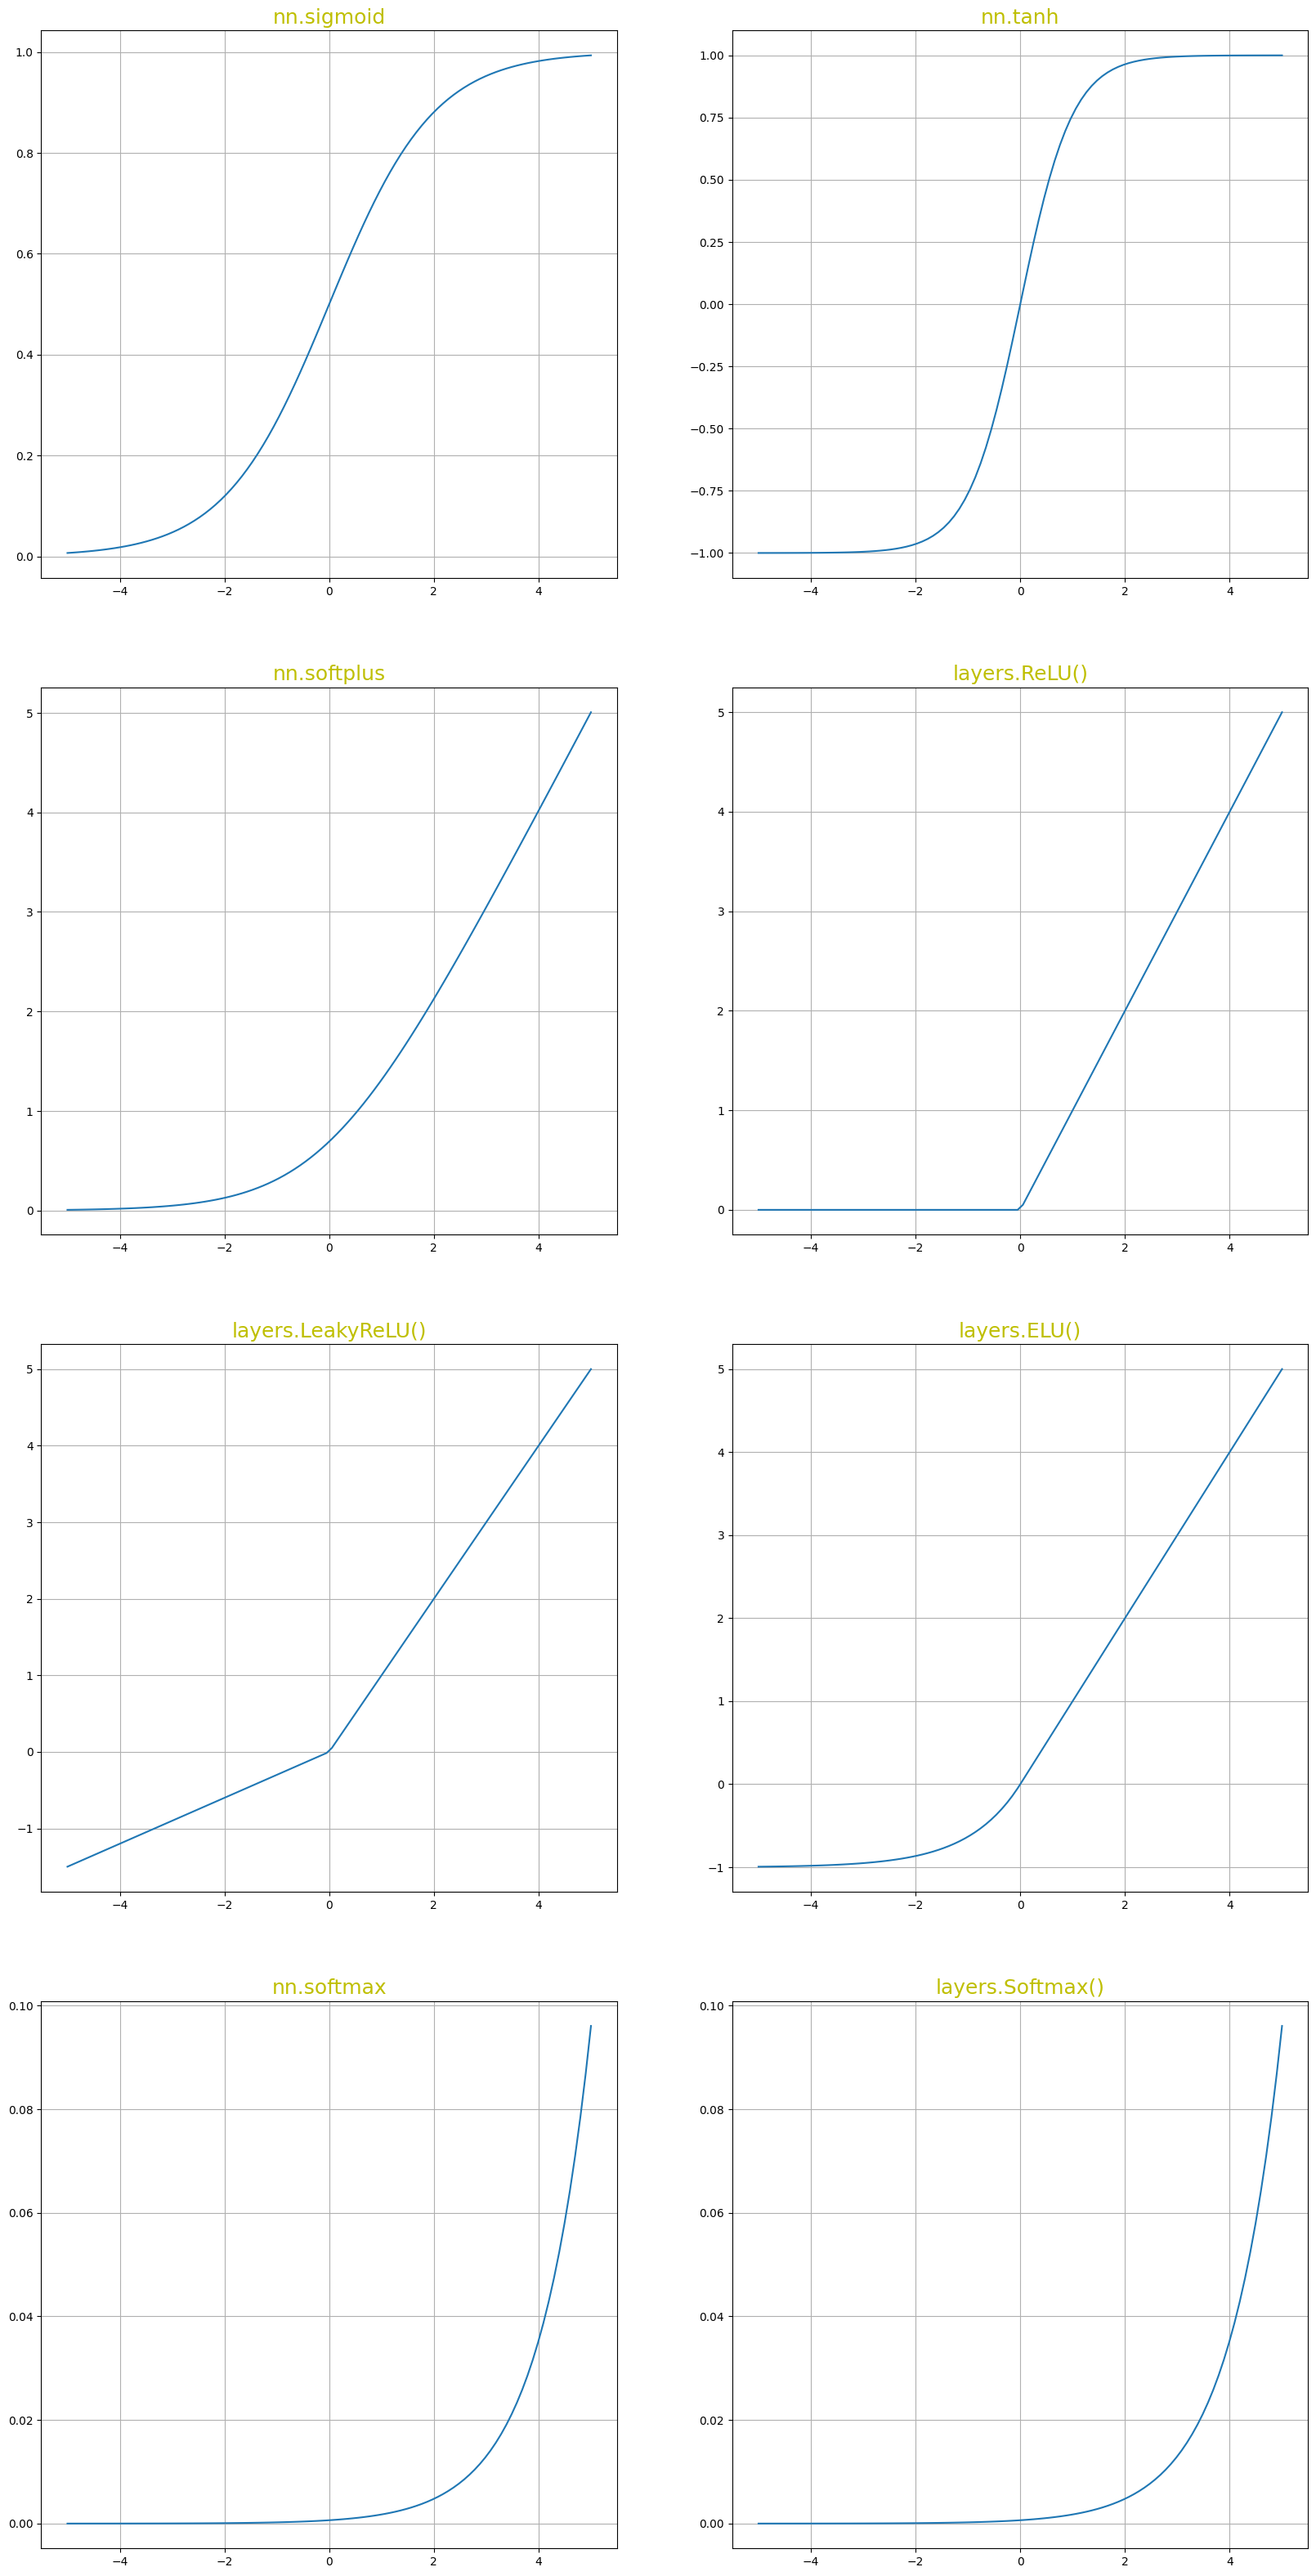

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import nn
from tensorflow.keras import layers
# fake data
x = np.linspace(-5, 5, 100, dtype=np.float32).reshape(1, -1)
 
#激活函数
activations=['nn.sigmoid','nn.tanh','nn.softplus','layers.ReLU()','layers.LeakyReLU()','layers.ELU()','nn.softmax','layers.Softmax()']

ys=[ eval(f)(x).numpy().flatten() for f in  activations]#激活函数计算
 
fig,axes=plt.subplots(ncols=2,nrows=4,figsize=(20,40))
x_plot = x.flatten()
for i,(label,y) in enumerate(zip(activations,ys)):
    axes[i//2][i%2].plot(x_plot,y)
    axes[i//2][i%2].set_title(label,color='y',fontsize=18)
    axes[i//2][i%2].grid()
plt.show()

#### 6）其他层
- tf.keras.layers.GlobalAveragePooling2D(data_format=None):全局平均池化层，每一个通道的所有数据取一个平均值输出，也即最后通道数就等于输出的单元数

- tf.keras.layers.GlobalMaxPool2D(data_format=None):全局最大池化层，每一个通道的所有数据取一个最大值输出，也即最后通道数就等于输出的单元数

- tf.keras.layers.Dropout(rate)：求平均值

    - rate：即 dropout rate，如设置为 0.1，则意味着会丢弃 10% 的神经元。

- tf.keras.layers.BatchNormalization：批量归一化层

    - axis:整数，用来指定进行批量归一化的轴(典型值是特征轴)；例如，如果你的
    - data_format="channels_first"，那么就应该设置axis=1，否则应该设置为-1
    - center：表示归一化时是否加上beta偏移量，可见下面公式的最后一个式子
    - scale：表示归一化时是否乘上gamma系数，可见下面公式的最后一个式子
    - momentum：在按特征规范化时，计算数据的指数平均数和标准差时的动量
    - epsilon：大于0的小浮点数，用于防止除0错误
    - beta_initializer：beta的初始化器
    - gamma_initializer：gamma的初始化器。
    - moving_mean_initializer：移动平均初始化器。
    - moving_variance_initializer：移动方差初始化器。
    - beta_regularizer：beta的正则化器。
    - gamma_regularizer：gamma的正则化器。

- tf.keras.layers.UpSampling2D(size=(2, 2), data_format=None, interpolation='nearest')：上采样层，用于扩大特征层尺寸

    - size:可以是一个整数或者两个整数组成的元组，分别表示宽和高两个维度上的上采样因子，也就是尺寸变成原来的多少倍
    - data_format：默认是channels_last，还可以设置为channels_first，用来表示通道维位置
    - interpolation：上采样时插值方式，可以设置为nearest或者bilinear

- tf.keras.layers.Reshape(target_shape=(7 * 7 * 64)): reshape层

### Tensorflow建模三板斧
三种建模方式：

- Sequential Model(顺序模型)
- Functional Model(函数模型)
- SubClassing Model(子类化模型)

#### 1）Sequential Model(顺序模型)
对于常见的网络，需要手动调用每一层的类实例完成前向传播运算，当网络层数变得较深时，这一部分代码显得非常臃肿。

最典型和常用的神经网络结构是将一堆层按特定顺序叠加起来，那么，我们是不是只需要提供一个层的 列表，就能由 Keras 将它们自动首尾相连，形成模型呢？

可以通过 Keras 提供的网络容器 Sequential 将多个网络层封装成一个大网络模型，只需要调用网络模型的实例一次即可完成数据从第一层到最末层的顺序运算。

例如，2 层的全连接层加上单独的激活函数层，可以通过 Sequential 容器封装为一个网络:

In [26]:
# 导入Sequential容器
import tensorflow as tf
from tensorflow.keras import layers, Sequential
network = Sequential([ # 封装为一个网络
    layers.Dense(3, activation=None), # 全连接层
    layers.ReLU(),#激活函数层
    layers.Dense(2, activation=None), # 全连接层
    layers.ReLU() #激活函数层
])
x = tf.random.normal([4, 5])
network(x)  # 输入从第一层开始，逐层传播至最末层
#network.summary()

<tf.Tensor: shape=(4, 2), dtype=float32, numpy=
array([[0.0392032 , 0.19302714],
       [0.        , 0.        ],
       [0.1633446 , 0.8042696 ],
       [0.23436901, 1.02611   ]], dtype=float32)>

Sequential 容器也可以通过 ***add()方法继续追加新的网络层***，实现动态创建网络的功能：

下列代码通过指定任意的 layers_num 参数即可创建对应层数的网络结构，在完成网络创建时，很多类并没有创建内部权值张量等成员变量，此时通过调用类的 build 方法并指定输入大小，即可自动创建所有层的内部张量。通过 summary()函数可以方便打印出网络结构和参数量：

In [29]:
layer_nums = [3, 2] # 根据这个变量创建层数
network = Sequential([]) # 先创建空的网络
for num in layer_nums:
    network.add(layers.Dense(num)) # 添加全连接层
    network.add(layers.ReLU()) # 添加激活函数层
network.build(input_shape = (None, 5)) # 指定输入的x形状，创建网络参数
network.summary() # 注意第一行，参数18 = 输入到第一层之间的w（5 * 3 = 15）+ 3个b参数，第二个Dense同理

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 3)                 18        
                                                                 
 re_lu_12 (ReLU)             (None, 3)                 0         
                                                                 
 dense_23 (Dense)            (None, 2)                 8         
                                                                 
 re_lu_13 (ReLU)             (None, 2)                 0         
                                                                 
Total params: 26 (104.00 Byte)
Trainable params: 26 (104.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


当我们通过 Sequential 容量封装多层网络层时，所有层的参数列表将会自动并入Sequential 容器的参数列表中，不需要人为合并网络参数列表。Sequential 对象的trainable_variables 和 variables 包含了所有层的待优化张量列表和全部张量列表：

In [30]:
# 打印网络的待优化参数名与 shape
for p in network.variables:
    print(p.name, p.shape)

#修改参数是否可训练
network.layers[0].trainable = False
for p in network.trainable_variables:
    print(p.name, p.shape)

dense_22/kernel:0 (5, 3)
dense_22/bias:0 (3,)
dense_23/kernel:0 (3, 2)
dense_23/bias:0 (2,)
dense_23/kernel:0 (3, 2)
dense_23/bias:0 (2,)


#### 2）Functional Model(函数模型)
Sequential这种层叠结构并不能表示任意的神经网络结构。复杂模型怎么办?

- 多输入模型
- 多输出模型
- 具有共享图层（同一图层被调用多次）的模型
- 具有非顺序数据流的模型（例如，残余连接）

Keras 提供了 Functional API ，帮 助我们建立更为复杂的模型，例如多输入 / 输出或存在参数共享的模型。其使用方法是将层作为可调用的对象并返回张量，并将输入向量和输出向量提供给 tf.keras.Model 的 inputs 和 outputs 参数，示例如下：

In [32]:
inputs = tf.keras.layers.Input(shape = (32,)) # 指定输入  可以有多个

x = layers.Dense(64, activation = 'relu')(inputs) # 直接调用对象执行  call
x = layers.Dense(64, activation = 'relu')(x)
predictions = layers.Dense(10)(x)

# 模型编译
model = tf.keras.Model(inputs = inputs, outputs = predictions)
model.summary()
xx = tf.random.normal([4, 32])
model(xx).shape

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32)]              0         
                                                                 
 dense_27 (Dense)            (None, 64)                2112      
                                                                 
 dense_28 (Dense)            (None, 64)                4160      
                                                                 
 dense_29 (Dense)            (None, 10)                650       
                                                                 
Total params: 6922 (27.04 KB)
Trainable params: 6922 (27.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


TensorShape([4, 10])

In [33]:
inputs1 = tf.keras.layers.Input(shape=(32,))
inputs2 = tf.keras.layers.Input(shape=(32,))

x1 = layers.Dense(64, activation = 'relu')(inputs1)
x2 = layers.Dense(64, activation = 'relu')(inputs2)
x = tf.concat([x1, x2], axis = -1) # 进行拼接
x = layers.Dense(64, activation = 'relu')(x)
predictions = layers.Dense(10)(x)

# 模型编译
model = tf.keras.Model(inputs = [inputs1, inputs2], outputs = predictions)
model.summary()
xx1 = tf.random.normal([4,32])
xx2 = tf.random.normal([4,32])
model((xx1, xx2)).shape

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 32)]                 0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 32)]                 0         []                            
                                                                                                  
 dense_30 (Dense)            (None, 64)                   2112      ['input_3[0][0]']             
                                                                                                  
 dense_31 (Dense)            (None, 64)                   2112      ['input_4[0][0]']             
                                                                                            

TensorShape([4, 10])

#### 3）子类化模型
- 通过子类化tfkeras.Model和定义自己的前向传播模型来构建完全可定制的模型。
- 和eager execution模式相辅相成
- Keras 模型以类的形式呈现，我们可以通过继承 tf.keras.Model 这个 Python 类来定义自己的模 型。在继承类中，我们需要重写 init() （构造函数，初始化）和 call(input) （模型调用）两 个方法，同时也可以根据需要增加自定义的方法。

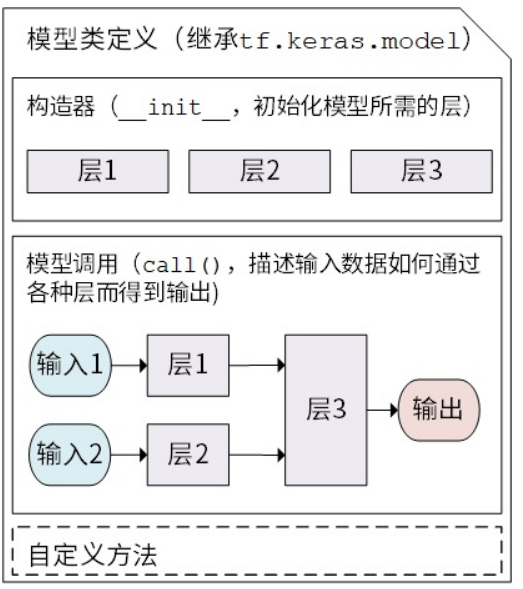

In [35]:
class MyModel(tf.keras.Model):
    def __init__(self, num_classes = 10):
        super(MyModel, self).__init__(name = 'my_model')
        self.num_classes = num_classes
        self.dense_1 = layers.Dense(32, activation = 'relu')
        self.dense_2 = layers.Dense(num_classes)
    def call(self, inputs):
        # 定义前向传播
        # 使用在__init__方法中定义的层
        x = self.dense_1(inputs)
        return self.dense_2(x)

# 实例化模型
model = MyModel(num_classes = 10)

x = tf.random.normal([4, 32])
print(model(x).shape)

model.summary()

(4, 10)
Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            multiple                  1056      


                                                                 
 dense_37 (Dense)            multiple                  330       
                                                                 
Total params: 1386 (5.41 KB)
Trainable params: 1386 (5.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### 4）三种方法的区别

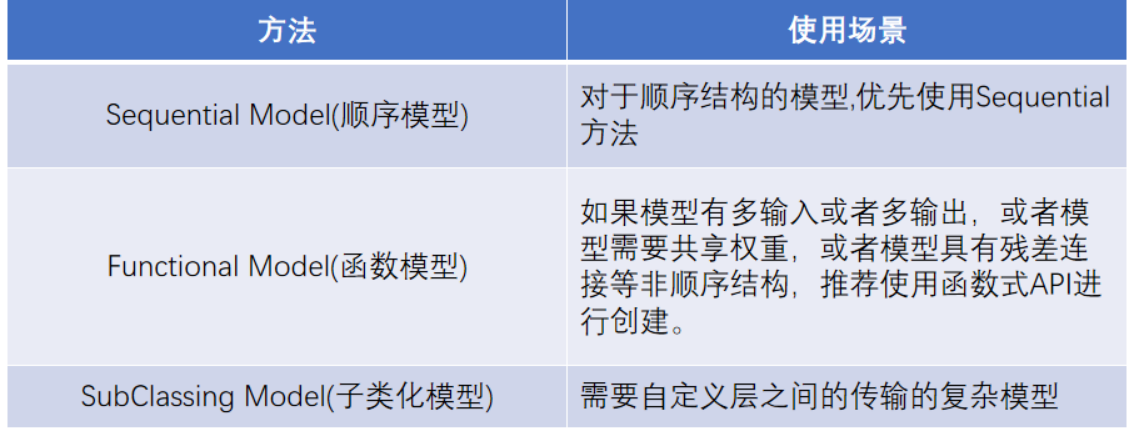

### 建模实战
#### 1）自定义层
如果现有的这些层无法满足我的要求，我需要定义自己的层怎么办？

事实上，我们不仅 可以继承 tf.keras.Model 编写自己的模型类，也可以继承 tf.keras.layers.Layer 编写自己的层。

实现自定义层的最佳方法是扩展 tf.keras.layers.Layer 类并实现：

- __init__ ：可以在其中进行所有与输入无关的初始化，定义相关的层
- build：知道输入张量的形状并可以进行其余的初始化
- call：在这里进行前向传播

**注意：不一定需要在build中创建变量时，也可以在__init__中创建它们。**

In [ ]:
class MyLayer(tf.keras.layers.Layer):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        # 初始化代码
    def build(self, input_shape): # input_shape 是一个 TensorShape 类型对象， 提供输入的形状
    # 在第一次使用该层的时候调用该部分代码，在这里创建变量可以使得变量的形状自适应输入的形状
    # 而不需要使用者额外指定变量形状。如果已经可以完全确定变量的形状，也可以在__init__部分创建变量
        self.variable_0 = self.add_weight(...)
        self.variable_1 = self.add_weight(...)
    def call(self, inputs):
    # 模型调用的代码（处理输入并返回输出）
        return output

例如，如果我们要自己实现一个自己的全连接层（ tf.keras.layers.Dense ），可以按如下方式编写。此代码在 build 方法中创建两个变量，并在 call 方法中使用创建的变量进行运算：

In [36]:
class LinearLayer(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__
        self.units = units # 输出的神经元个数
    def build(self, input_shape): # 这里 input_shape 是第一次运行call()时参数 inputs的形状 
        self.w = self.add_variable(name = 'w', 
                                   shape = [input_shape[-1], self.units], initializer = tf.zeros_initializer())
        self.b = self.add_variable(name = 'b',
                                   shape = [self.units], initializer = tf.zeros_initializer())
    def call(self, inputs):
        y_pred = tf.matmul(inputs, self.w) + self.b
        return y_pred

在定义模型的时候，我们便可以如同 Keras 中的其他层一样，调用我们自定义的层 LinearLayer ：

In [37]:
class LinearModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.layer = LinearLayer(units=1)
    def call(self, inputs):
        output = self.layer(inputs)
        return output

#### 2）resnet网络结构

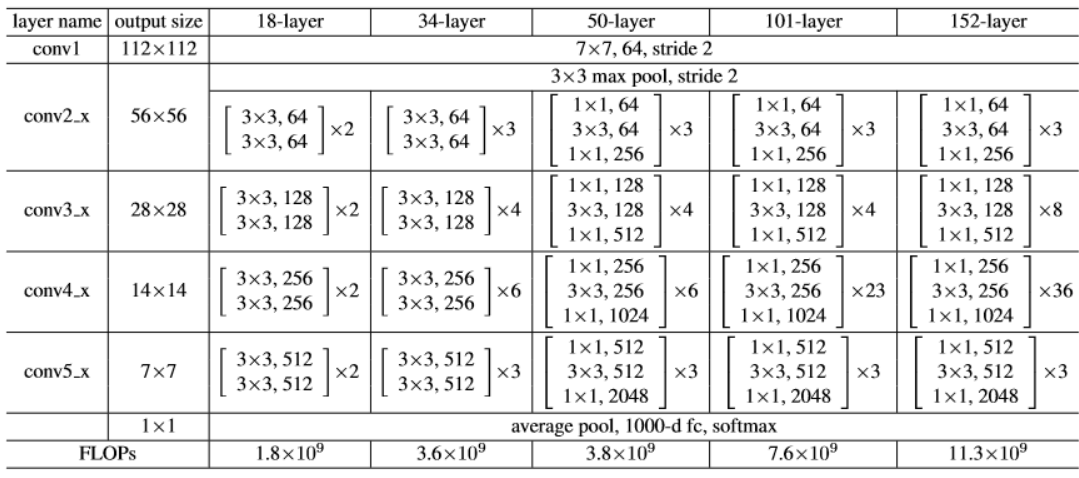

#### 3）搭建残差模块BasicBlock

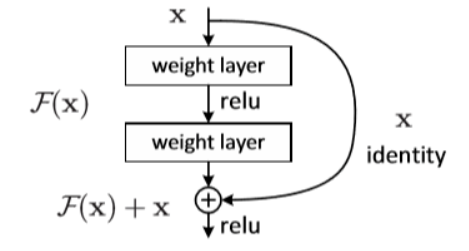

In [42]:
class BasicBlock(tf.keras.Model):
    def __init__(self, filter_num, stride = 1):
        super(BasicBlock, self).__init__()

        self.conv1 = layers.Conv2D(filter_num, (3, 3), strides = stride, padding = 'same')
        self.bn1 = layers.BatchNormalization() # BN层
        self.relu = layers.Activation('relu') # ReLU激活函数

        self.conv2 = layers.Conv2D(filter_num, (3, 3), strides = 1, padding = 'same')
        self.bn2 = layers.BatchNormalization()

        if stride != 1:
            self.downsample = Sequential() # 下采样，看block的图，X identity后面要和输出加权的，若步长不为1，则要调整形状保持一致
            self.downsample.add(layers.Conv2D(filter_num, (1, 1), strides = stride))
            self.downsample.add(tf.keras.layers.BatchNormalization())

        else:
            self.downsample = lambda x:x # 恒等映射

    def call(self, inputs, training = None):
        out = self.conv1(inputs)
        out = self.bn1(out, training = training)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out, training = training)

        identity = self.downsample(inputs) # 恒等映射
        output = layers.add([out, identity]) # 主路与支路相加
        output = tf.nn.relu(output) # ReLU激活函数
        return output

#### 4）搭建总体网络结构
依据上面给出的ResNet的体系结构表，我们能够先搭建出残差块函数（将几个相同的残差模块堆叠在一块儿）。而后再搭建总体结构，这样代码就会简化不少。

In [43]:
class ResNet(tf.keras.Model):
    def __init__(self, layer_nums, num_classes = 100):
        '''
        layer_nums:一个列表 [3,4,6,3]
        '''
        super(ResNet, self).__init__()
        # 第一层
        self.stem = Sequential([layers.Conv2D(64, (3, 3)),
                                layers.BatchNormalization(),
                                layers.Activation('relu'),
                                layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='same')]) # 224 -> 112
        # 中间层的四个残差块：conv2_x, conv3_x, conv4_x, conv5_x
        self.layer1 = self.build_resblock(64, layer_nums[0], stride=2) # 112 -> 56
        self.layer2 = self.build_resblock(128, layer_nums[1], stride=2) # 56->28
        self.layer3 = self.build_resblock(256, layer_nums[2], stride=2) # 28->14
        self.layer4 = self.build_resblock(512, layer_nums[3], stride=2) # 14->7
        # 全局平均池化
        self.avgpool = layers.GlobalAveragePooling2D() # 512
        # 全链接层
        self.fc = layers.Dense(num_classes) # 512 -> 1000

    def call(self, inputs, training=None):
        x = self.stem(inputs,training=training)
        x = self.layer1(x,training=training)
        x = self.layer2(x,training=training)
        x = self.layer3(x,training=training)
        x = self.layer4(x,training=training)
        x = self.avgpool(x)
        x = self.fc(x)
        return x

    # 构建残差块（将几个相同的残差模块堆叠在一起）
    def build_resblock(self, filter_num, blocks, stride = 1):
        res_blocks = Sequential()
        # 观察模型描述表格，一般进入一个block时可能会需要进行下采样
        res_blocks.add(BasicBlock(filter_num, stride)) # 步长为2, 实现下采样，特征图变小
        for _ in range(1, blocks):
            res_blocks.add(BasicBlock(filter_num, stride = 1)) # 后续步长变为1
        return res_blocks
    
network = ResNet([3, 4, 6, 3], num_classes = 10)
network.build(input_shape = (None, 224, 224, 3))
network.summary()

Model: "res_net_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_24 (Sequential)  (None, 111, 111, 64)      2048      
                                                                 
 sequential_25 (Sequential)  (None, 56, 56, 64)        227520    
                                                                 
 sequential_27 (Sequential)  (None, 28, 28, 128)       1119872   
                                                                 
 sequential_29 (Sequential)  (None, 14, 14, 256)       6832384   
                                                                 
 sequential_31 (Sequential)  (None, 7, 7, 512)         13125120  
                                                                 
 global_average_pooling2d_2  multiple                  0         
  (GlobalAveragePooling2D)                                       
                                                         

In [44]:
for p in network.variables:
    print(p.name, p.shape)

conv2d_75/kernel:0 (3, 3, 3, 64)
conv2d_75/bias:0 (64,)
batch_normalization_74/gamma:0 (64,)
batch_normalization_74/beta:0 (64,)
batch_normalization_74/moving_mean:0 (64,)
batch_normalization_74/moving_variance:0 (64,)
basic_block_32/conv2d_76/kernel:0 (3, 3, 64, 64)
basic_block_32/conv2d_76/bias:0 (64,)
basic_block_32/batch_normalization_75/gamma:0 (64,)
basic_block_32/batch_normalization_75/beta:0 (64,)
basic_block_32/batch_normalization_75/moving_mean:0 (64,)
basic_block_32/batch_normalization_75/moving_variance:0 (64,)
basic_block_32/conv2d_77/kernel:0 (3, 3, 64, 64)
basic_block_32/conv2d_77/bias:0 (64,)
basic_block_32/batch_normalization_76/gamma:0 (64,)
basic_block_32/batch_normalization_76/beta:0 (64,)
basic_block_32/batch_normalization_76/moving_mean:0 (64,)
basic_block_32/batch_normalization_76/moving_variance:0 (64,)
conv2d_78/kernel:0 (1, 1, 64, 64)
conv2d_78/bias:0 (64,)
batch_normalization_77/gamma:0 (64,)
batch_normalization_77/beta:0 (64,)
batch_normalization_77/moving_m